<a href="https://colab.research.google.com/github/DianaKhanyaf/Thesis/blob/main/MasterThesisFinal_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re

In [ ]:
import zipfile
import os
from google.colab import files

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
from transformers import pipeline

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

# 1.Dataset in zip --> folder with txt files

Upload the zip folder with the txt files (the dataset) to the colab and save them into a list so that they can be looped over and each of them is separated into evaluations

result: directory with all txt files -- one txt=evaluations of one semester

In [ ]:
def prepare_colab_directory():
    # Upload a zip-directory from the computer
    uploaded = files.upload()

    # Get the name of the uploaded zip-dir.
    zip_file_name = list(uploaded.keys())[0]

    # Unzip the uploaded file
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('unzipped_folder1')

    # Get a list of .txt files in the directory
    txt_files = []
    for filename in os.listdir('unzipped_folder1'):
        file_path = os.path.join('unzipped_folder1', filename)
        txt_files.append(file_path)  # Add the file path to the list of files

    return txt_files

#2.Separate into evaluations

Save the data set in the dictionary format

result: {'Winter_2023_en_S1f_1': ["The last block was a great .....

values are whole evaluations

In [ ]:
def separate_into_evaluations(input_file):
    evaluations = {}
    key, reaktionsblatt, body = None, None, ''

    with open(input_file, 'r', encoding='utf-8') as file:
        for line in file:
            # Search for first key-pattern: S[0-9]+[wfm]
            key_match = re.search(r'S[0-9]+[wfm]', line)

            # Search for third key patter: Reaktionsblatt or Block followed by a digit
            reaktionsblatt_match = re.search(r'(Reaktionsblatt|Block)\s+(\d+)', line)

            # Search for second key-pattern: a single digit on a line (could've been handeled as an exception and added manually in the data set)
            digit_match = re.match(r'^\s*(\d+)\s*$', line)

            if key_match:
                # Append current body to the corresponding key if already exists
                if key:
                    evaluations.setdefault(key, []).append(body.strip())

                # Set key as S[0-9]+[wfm]
                key = key_match.group()

                # Set Reaktionsblatt as matched group
                reaktionsblatt = reaktionsblatt_match.group(2) if reaktionsblatt_match else reaktionsblatt

                # Append the reaktionsblatt number to the key
                key += f"_{reaktionsblatt}" if reaktionsblatt else ""

                # Prepend the filename without .txt extension to the key
                filename_without_ext = os.path.splitext(os.path.basename(input_file))[0]  # Remove the .txt extension
                key = f"{filename_without_ext}_{key}"

                # Start a new body for this key
                body = line[key_match.end():].strip()

            elif reaktionsblatt_match:
                reaktionsblatt = reaktionsblatt_match.group(2)

            elif digit_match:
                reaktionsblatt = digit_match.group(1)

            elif key:
                # If we're inside a section for a key, continue adding to the body
                body += ' ' + line.strip()

        # Add the final key and body to the dictionary at the end of the file
        if key:
            evaluations.setdefault(key, []).append(body.strip())

    return evaluations

#3.Save into excel, per sentence

In [ ]:
def dataset_per_sentence_excel (evaluations_dict):

    data_for_excel = []

    for key, evaluations in evaluations_dict.items():
        # Split key: Winter_2023_en_S1f_1 into Semester (Winter_2023), Language (en), Student ID (S1f), and Reaktionsblatt (1)
        parts = key.split("_")
        semester = f"{parts[0]}_{parts[1]}"  # Combine "Winter" and "2023" as "Winter_2023"
        language = parts[2]   # "en"
        student_id = parts[3]  # "S1f"
        reaktionsblatt = parts[4]  # "1"

        # Process each evaluation in the list
        for evaluation in evaluations:
            sentences = re.split(r'(?<=[.!?])\s+', evaluation)
            for sentence_num, sentence in enumerate(sentences, start=1):
                if sentence.strip():  # Avoid empty sentences
                    data_for_excel.append([
                        semester, language, student_id, reaktionsblatt, sentence_num, sentence.strip(), "", "", "", "", "", ""
                    ])  # Empty fields for Labels and Predictions

    columns = [
        'Semester',
        'Language',
        'Student ID',
        'Reaktionsblatt/Block',
        'Sentence Number',
        'Evaluation Text',
        'Label_Positive', 'Label_Neutral', 'Label_Negative',
        'Prediction_Positive', 'Prediction_Neutral', 'Prediction_Negative'
    ]

    df = pd.DataFrame(data_for_excel, columns=columns)

    excel_filename = 'dataset_per_sentence.xlsx'
    df.to_excel(excel_filename, index=False)

    files.download(excel_filename)

#4.Compile the dataset per evaluation out of the dataset per sentence
January 2026

excel with the dataset per sentences, i did there the labeling and adjusted some things. so that the dataset per sentence and per evaluation are consistent, the excel per sentence is used to make an excel per evaluation out of it. to ensure correct display of umlauts, they are normalized with ASCII equivalents beforehand

In [ ]:
def normalize_german_umlauts_columnF(input_excel, output_excel):
    """
    Reads an Excel file and replaces German umlauts with ASCII equivalents
    (ä → ae, ö → oe, ü → ue, ß → ss) in column F (6th column),
    then saves the result to a new Excel file.
    """

    # Mapping of German umlauts to ASCII equivalents
    umlaut_map = {
        "ä": "ae",
        "ö": "oe",
        "ü": "ue",
        "Ä": "Ae",
        "Ö": "Oe",
        "Ü": "Ue",
        "ß": "ss"
    }

    # Function to replace umlauts in a string
    def replace_umlauts(text):
        if not isinstance(text, str):
            return text
        for umlaut, replacement in umlaut_map.items():
            text = text.replace(umlaut, replacement)
        return text

    # Read Excel safely
    df = pd.read_excel(input_excel, engine='openpyxl', dtype=str)

    # Get the 6th column (column F) by position
    col_index = 5  # zero-based index, F is 5
    if col_index >= len(df.columns):
        raise ValueError("Excel does not have column F (6th column)")

    col_name = df.columns[col_index]

    # Replace umlauts in that column
    df[col_name] = df[col_name].apply(replace_umlauts)

    # Force all columns to string
    df = df.astype(str)

    # Save Excel safely
    df.to_excel(output_excel, index=False, engine='openpyxl')
    print(f"Normalized Excel saved to {output_excel} with ASCII umlauts in column F.")
    return df


In [ ]:
normalize_german_umlauts("sentence_do_labeling_first_sheet.xlsx", "sentence_do_labeling_first_sheet_without_umlauts.xlsx")

from dataset per sentence to dataset per evaluation

In [ ]:
def restructure_excel_with_chunks_2(input_excel, output_excel, max_words=300):
    """
    Groups sentence-level rows from an Excel into evaluation-level chunks.
    Uses the same chunking logic as dataset_per_300words_excel:
    - Sentence-aware
    - Cumulative word count
    - Multiple chunks if necessary
    """

    df = pd.read_excel(input_excel)
    output_rows = []

    group_cols = ['Semester', 'Language', 'Student ID', 'Reaktionsblatt/Block']

    for _, group in df.groupby(group_cols, sort=False):
        group = group.sort_values('Sentence Number')

        # Combine all sentences into a single evaluation string
        evaluation_text = " ".join([str(s).strip() for s in group['Evaluation Text'] if str(s).strip()])

        # Split evaluation into sentences (preserves abbreviations)
        sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?)\s', evaluation_text)

        chunk = []
        chunk_word_count = 0
        chunk_number = 1

        for sentence in sentences:
            sentence = sentence.strip()
            if not sentence:
                continue

            sentence_word_count = len(sentence.split())

            # Start new chunk if adding sentence exceeds max_words
            if chunk_word_count + sentence_word_count > max_words and chunk:
                # Save current chunk
                base_row = group.iloc[0].copy()
                base_row['Evaluation Text'] = " ".join(chunk).strip()
                base_row['Chunk Number'] = chunk_number
                output_rows.append(base_row)

                # Start new chunk
                chunk = [sentence]
                chunk_word_count = sentence_word_count
                chunk_number += 1
            else:
                # Add sentence to current chunk
                chunk.append(sentence)
                chunk_word_count += sentence_word_count

        # Save the last chunk
        if chunk:
            base_row = group.iloc[0].copy()
            base_row['Evaluation Text'] = " ".join(chunk).strip()
            base_row['Chunk Number'] = chunk_number
            output_rows.append(base_row)

    out_df = pd.DataFrame(output_rows)

    # Drop columns no longer needed
    out_df.drop(columns=['Sentence Number',
                         'Label_Positive',
                         'Label_Neutral',
                         'Label_Negative'],
                errors='ignore',
                inplace=True)

    # Save the restructured Excel
    out_df.to_excel(output_excel, index=False)

    print(f"Excel restructured and saved to {output_excel}")


In [ ]:
restructure_excel_with_chunks_2("sentence_do_labeling_first_sheet_without_umlauts__no_labels.xlsx", "per_evaluation.xlsx")

Excel restructured and saved to per_evaluation.xlsx


#5.Analysis with LM; manipulation of predicated and gold standard labels; aggregation of evaluation text separated into chunks

In [ ]:
distilled_student_sentiment_classifier = pipeline(
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    return_all_scores=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


initiallty, when i first tried this out, all and each chunck no longer than 300 words could be processed by the LM. this was not the case anymore after i restructured the excel. the solution was to add a try-except block. longer evaluation that could not have been processed because of their tensor size were split manually and run through the model manully. there were 4 such evaluations or chuncks of evaluations

In [ ]:
def sentiment_analysis_skip_errors(input_excel):
    """

    Apply sentiment analysis to Evaluation Text in an Excel file.
    If a chunk causes a tensor size error, it is skipped and prediction columns are left empty.
    Saves results to a new Excel file with prefix 'LM_predictions_'.
    """

    df = pd.read_excel(input_excel)

    positive_scores = []
    neutral_scores = []
    negative_scores = []

    for sentence in df['Evaluation Text']:
        if isinstance(sentence, str) and sentence.strip():
            try:
                # Run the model
                sentiment_scores = distilled_student_sentiment_classifier(sentence)
                positive_scores.append(sentiment_scores[0][0]['score'])
                neutral_scores.append(sentiment_scores[0][1]['score'])
                negative_scores.append(sentiment_scores[0][2]['score'])
            except Exception as e:
                # If an error occurs (e.g., tensor size), skip this chunk
                print(f"Skipped a chunk due to error: {e}")
                positive_scores.append(None)
                neutral_scores.append(None)
                negative_scores.append(None)
        else:
            # Non-text or empty cells
            positive_scores.append(None)
            neutral_scores.append(None)
            negative_scores.append(None)

    # Add the prediction columns
    df['Prediction_Positive'] = positive_scores
    df['Prediction_Neutral'] = neutral_scores
    df['Prediction_Negative'] = negative_scores

    # Fill empty label columns (original ones) with zeros if they exist
    for column in ['Label_Positive', 'Label_Neutral', 'Label_Negative']:
        if column in df.columns:
            df[column].fillna(0, inplace=True)

    # Save to new Excel
    output_excel = f"LM_predictions_{input_excel}"
    df.to_excel(output_excel, index=False)

    print(f"Sentiment analysis completed. Results saved to '{output_excel}'")

In [ ]:
sentiment_analysis_skip_errors("per_evaluation (2).xlsx")

Skipped a chunk due to error: The size of tensor a (577) must match the size of tensor b (512) at non-singleton dimension 1
Skipped a chunk due to error: The size of tensor a (555) must match the size of tensor b (512) at non-singleton dimension 1
Skipped a chunk due to error: The size of tensor a (543) must match the size of tensor b (512) at non-singleton dimension 1
Skipped a chunk due to error: The size of tensor a (515) must match the size of tensor b (512) at non-singleton dimension 1
Sentiment analysis completed. Results saved to 'LM_predictions_per_evaluation (2).xlsx'


/tmp/ipython-input-890950257.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(0, inplace=True)


In [ ]:
sentiment_analysis_skip_errors("sentence_do_labeling_first_sheet_without_umlauts__no_labels.xlsx")

/tmp/ipython-input-1714909827.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(0, inplace=True)


Sentiment analysis completed. Results saved to 'LM_predictions_sentence_do_labeling_first_sheet_without_umlauts__no_labels.xlsx'


In [ ]:
def binarize_sentence_level_predictions(input_excel):
    """
    Converts sentence-level prediction scores into binary labels.
    For each row, the maximum of Prediction_Positive / Neutral / Negative
    is set to 1, the others to 0.
    Rows with missing predictions remain empty.
    """

    df = pd.read_excel(input_excel)

    pred_cols = [
        'Prediction_Positive',
        'Prediction_Neutral',
        'Prediction_Negative'
    ]

    def binarize_row(row):
        values = row[pred_cols]

        # If predictions are missing (e.g. skipped due to tensor error)
        if values.isna().all():
            return pd.Series([np.nan, np.nan, np.nan], index=pred_cols)

        max_col = values.idxmax()

        return pd.Series(
            [1 if col == max_col else 0 for col in pred_cols],
            index=pred_cols
        )

    df[pred_cols] = df.apply(binarize_row, axis=1)

    output_excel = f"binary_sentence_predictions_{input_excel}"
    df.to_excel(output_excel, index=False)

    print(f"Binary sentence-level predictions saved to '{output_excel}'")


In [ ]:
binarize_sentence_level_predictions("LM_predictions_sentence_do_labeling_first_sheet_without_umlauts__no_labels.xlsx")

Binary sentence-level predictions saved to 'binary_sentence_predictions_LM_predictions_sentence_do_labeling_first_sheet_without_umlauts__no_labels.xlsx'


In [ ]:
def aggregate_chunks_to_evaluations(input_excel, output_excel):
    """
    Aggregates chunk-level predictions into evaluation-level predictions.
    - Averages Prediction_* columns across chunks
    - Joins all chunk texts into one Evaluation Text
    - Outputs one row per evaluation
    """

    df = pd.read_excel(input_excel)

    group_cols = [
        'Semester',
        'Language',
        'Student ID',
        'Reaktionsblatt/Block'
    ]

    aggregated_rows = []

    for _, group in df.groupby(group_cols, sort=False):
        group = group.sort_values('Chunk Number')

        base_row = group.iloc[0].copy()

        # --- Join evaluation text ---
        full_text = " ".join(
            group['Evaluation Text']
            .dropna()
            .astype(str)
        )

        # --- Average predictions ---
        avg_positive = group['Prediction_Positive'].mean(skipna=True)
        avg_neutral  = group['Prediction_Neutral'].mean(skipna=True)
        avg_negative = group['Prediction_Negative'].mean(skipna=True)

        base_row['Evaluation Text'] = full_text
        base_row['Prediction_Positive'] = avg_positive
        base_row['Prediction_Neutral'] = avg_neutral
        base_row['Prediction_Negative'] = avg_negative

        aggregated_rows.append(base_row)

    out_df = pd.DataFrame(aggregated_rows)

    # Drop chunk-specific column
    out_df.drop(columns=['Chunk Number'], errors='ignore', inplace=True)

    out_df.to_excel(output_excel, index=False)

    print(f"Evaluation-level predictions saved to '{output_excel}'")


In [ ]:
aggregate_chunks_to_evaluations("LM_predictions_per_evaluation.xlsx", "LM_predictions_per_evaluation_no_chunks.xlsx")

Evaluation-level predictions saved to 'LM_predictions_per_evaluation_no_chunks.xlsx'


In [ ]:
def aggregate_labels_per_evaluation(input_excel, output_excel):
    """
    Aggregates sentence-level labels into evaluation-level averages.
    Groups by Semester, Language, Student ID, Reaktionsblatt/Block.
    """

    df = pd.read_excel(input_excel)

    group_cols = [
        'Semester',
        'Language',
        'Student ID',
        'Reaktionsblatt/Block'
    ]

    aggregated_rows = []

    for _, group in df.groupby(group_cols, sort=False):
        group = group.sort_values('Sentence Number')

        base_row = group.iloc[0].copy()

        # --- Join full evaluation text ---
        full_text = " ".join(
            group['Evaluation Text']
            .dropna()
            .astype(str)
        )

        # --- Average gold labels ---
        base_row['Label_Positive'] = group['Label_Positive'].mean()
        base_row['Label_Neutral']  = group['Label_Neutral'].mean()
        base_row['Label_Negative'] = group['Label_Negative'].mean()

        base_row['Evaluation Text'] = full_text

        aggregated_rows.append(base_row)

    out_df = pd.DataFrame(aggregated_rows)

    # Drop sentence-level column
    out_df.drop(columns=['Sentence Number'], errors='ignore', inplace=True)

    out_df.to_excel(output_excel, index=False)

    print(f"Averaged labels per evaluation saved to '{output_excel}'")


In [ ]:
aggregate_labels_per_evaluation("LM_predictions_sentence_do_labeling_first_sheet_without_umlauts__no_labels.xlsx", "LM_predictions_per_evaluation_no_chunks.xlsx")

Averaged labels per evaluation saved to 'LM_predictions_per_evaluation_no_chunks.xlsx'


In [ ]:
def merge_gold_labels_and_binarize(
    sentence_excel,
    evaluation_excel,
    output_soft_excel,
    output_hard_excel
):
    """
    1) Averages gold-standard sentence labels
    2) Inserts them into evaluation-level Excel
    3) Outputs:
       - soft (averaged)
       - hard (argmax → 1 / 0)
    """

    # --- Load data ---
    sent_df = pd.read_excel(sentence_excel)
    eval_df = pd.read_excel(evaluation_excel)

    group_cols = [
        'Semester',
        'Language',
        'Student ID',
        'Reaktionsblatt/Block'
    ]

    # --- Aggregate gold labels from sentence-level ---
    gold_agg = (
        sent_df
        .groupby(group_cols)[
            ['Label_Positive', 'Label_Neutral', 'Label_Negative']
        ]
        .mean()
        .reset_index()
    )

    # --- Merge into evaluation-level dataset ---
    merged = eval_df.merge(
        gold_agg,
        on=group_cols,
        how='left',
        suffixes=('', '_gold')
    )

    # Overwrite label columns with averaged gold labels
    for col in ['Label_Positive', 'Label_Neutral', 'Label_Negative']:
        merged[col] = merged[f"{col}_gold"]
        merged.drop(columns=f"{col}_gold", inplace=True)

    # --- Save SOFT output ---
    merged.to_excel(output_soft_excel, index=False)

    # --- Create HARD (argmax) version ---
    hard = merged.copy()

    def argmax_to_one(row, cols):
        max_col = row[cols].astype(float).idxmax()
        for c in cols:
            row[c] = 1 if c == max_col else 0
        return row

    label_cols = ['Label_Positive', 'Label_Neutral', 'Label_Negative']
    pred_cols  = ['Prediction_Positive', 'Prediction_Neutral', 'Prediction_Negative']

    hard = hard.apply(lambda r: argmax_to_one(r, label_cols), axis=1)
    hard = hard.apply(lambda r: argmax_to_one(r, pred_cols), axis=1)

    # --- Save HARD output ---
    hard.to_excel(output_hard_excel, index=False)

    print("✔ Soft gold-standard labels written to:", output_soft_excel)
    print("✔ Hard (argmax) labels & predictions written to:", output_hard_excel)


In [ ]:
merge_gold_labels_and_binarize(sentence_excel="LM_predictions_sentence_do_labeling_first_sheet_without_umlauts__no_labels.xlsx",
    evaluation_excel="LM_predictions_per_evaluation_no_chunks.xlsx",
    output_soft_excel="per_evaluation_not_binary.xlsx",
    output_hard_excel="per_evaluation_binary.xlsx")

✔ Soft gold-standard labels written to: per_evaluation_not_binary.xlsx
✔ Hard (argmax) labels & predictions written to: per_evaluation_binary.xlsx


In [ ]:
def plot_student_sentiment_curves(
    input_excel,
    semester_value,
    student_id=None,
    save_path=None
):
    """
    Two subplots for one semester:
    - Top: Gold labels
    - Bottom: LM predictions
    - Dots where LM != Gold are shown in red
    """

    # Read data
    df = pd.read_excel(input_excel)
    df = df[df['Semester'] == semester_value].copy()

    if student_id:
        df = df[df['Student ID'] == student_id].copy()
        if df.empty:
            print(f"No data found for student {student_id} in semester {semester_value}.")
            return

    # Convert labels to sentiment
    def sentiment(row, prefix):
        if row[f'{prefix}_Positive'] == 1:
            return 1
        elif row[f'{prefix}_Negative'] == 1:
            return -1
        else:
            return 0

    df['Gold_Sentiment'] = df.apply(lambda r: sentiment(r, 'Label'), axis=1)
    df['LM_Sentiment'] = df.apply(lambda r: sentiment(r, 'Prediction'), axis=1)

    # Aggregate per block
    agg = (
        df.groupby('Reaktionsblatt/Block')[['Gold_Sentiment', 'LM_Sentiment']]
        .mean()
        .reset_index()
        .sort_values('Reaktionsblatt/Block')
    )

    blocks = agg['Reaktionsblatt/Block'].tolist()
    x = np.arange(len(blocks))

    # Identify mismatches
    mismatch = agg['Gold_Sentiment'] != agg['LM_Sentiment']

    # 🔹 MAXIMALLY SQUEEZED FIGURE
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(10, 2.5),
        sharex=True
    )

    # --- Gold labels ---
    ax1.plot(
        x,
        agg['Gold_Sentiment'],
        linestyle='-',
        color='blue',
        linewidth=1.5
    )
    # Dots: mismatches in red
    ax1.scatter(
        x[~mismatch],
        agg['Gold_Sentiment'][~mismatch],
        color='blue',
        s=40
    )
    ax1.scatter(
        x[mismatch],
        agg['Gold_Sentiment'][mismatch],
        color='red',
        s=50
    )
    ax1.set_ylabel("Gold", labelpad=5)
    ax1.set_yticks([-1, 0, 1])
    ax1.set_ylim(-1.2, 1.2)
    ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

    # --- LM predictions ---
    ax2.plot(
        x,
        agg['LM_Sentiment'],
        linestyle='--',
        color='green',
        linewidth=1.5
    )
    # Dots: mismatches in red
    ax2.scatter(
        x[~mismatch],
        agg['LM_Sentiment'][~mismatch],
        color='green',
        s=40
    )
    ax2.scatter(
        x[mismatch],
        agg['LM_Sentiment'][mismatch],
        color='red',
        s=50
    )
    ax2.set_ylabel("LM", labelpad=5)
    ax2.set_yticks([-1, 0, 1])
    ax2.set_ylim(-1.2, 1.2)
    ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

    ax2.set_xlabel("Block")
    ax2.set_xticks(x)
    ax2.set_xticklabels(blocks, rotation=45)

    plt.tight_layout(h_pad=0.1)

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()


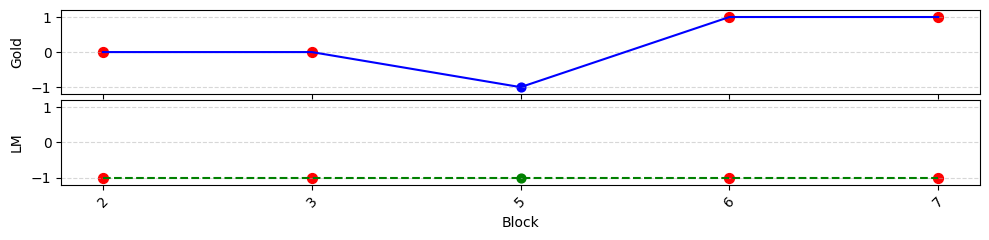

In [ ]:
plot_student_sentiment_curves("per_evaluation_binary.xlsx", "Winter_2019", "S16m")

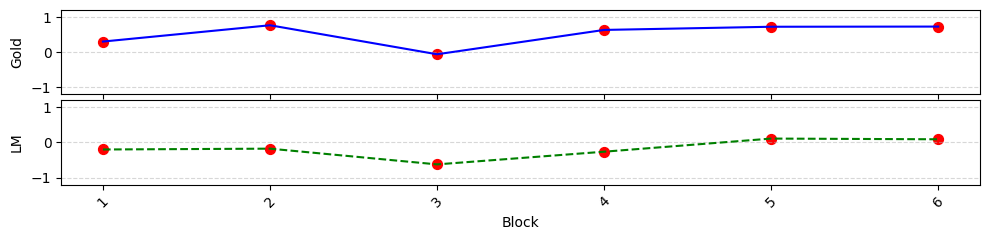

In [ ]:
plot_student_sentiment_curves("per_evaluation_binary.xlsx", "Winter_2020")

In [ ]:
def plot_sentiment_timeseries(input_excel, semester_value, normalize=False):
    """
    Plots time series of sentiment counts (or proportions) per block
    - One figure for Gold labels
    - One figure for LM predictions
    - normalize=True → plots proportion instead of raw counts
    """
    df = pd.read_excel(input_excel)
    df = df[df['Semester'] == semester_value].copy()

    blocks = sorted(df['Reaktionsblatt/Block'].unique())

    # --- Aggregate Gold labels ---
    gold_counts = df.groupby('Reaktionsblatt/Block')[
        ['Label_Positive', 'Label_Neutral', 'Label_Negative']
    ].sum().reindex(blocks, fill_value=0)

    if normalize:
        gold_counts = gold_counts.div(gold_counts.sum(axis=1), axis=0)

    # Plot Gold
    plt.figure(figsize=(12, 4))
    for col in gold_counts.columns:
        plt.plot(gold_counts.index, gold_counts[col], marker='o', label=col.replace('Label_', ''))
    plt.title("Gold Sentiment Over Blocks")
    plt.xlabel("Block")
    plt.ylabel("Count" if not normalize else "Proportion")
    plt.xticks(blocks)
    plt.yticks([0, 0.25, 0.5, 0.75, 1] if normalize else None)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Aggregate Predictions ---
    pred_counts = df.groupby('Reaktionsblatt/Block')[
        ['Prediction_Positive', 'Prediction_Neutral', 'Prediction_Negative']
    ].sum().reindex(blocks, fill_value=0)

    if normalize:
        pred_counts = pred_counts.div(pred_counts.sum(axis=1), axis=0)

    # Plot Predictions
    plt.figure(figsize=(12, 4))
    for col in pred_counts.columns:
        plt.plot(pred_counts.index, pred_counts[col], marker='x', linestyle='--', label=col.replace('Prediction_', ''))
    plt.title("LM Prediction Sentiment Over Blocks")
    plt.xlabel("Block")
    plt.ylabel("Count" if not normalize else "Proportion")
    plt.xticks(blocks)
    plt.yticks([0, 0.25, 0.5, 0.75, 1] if normalize else None)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


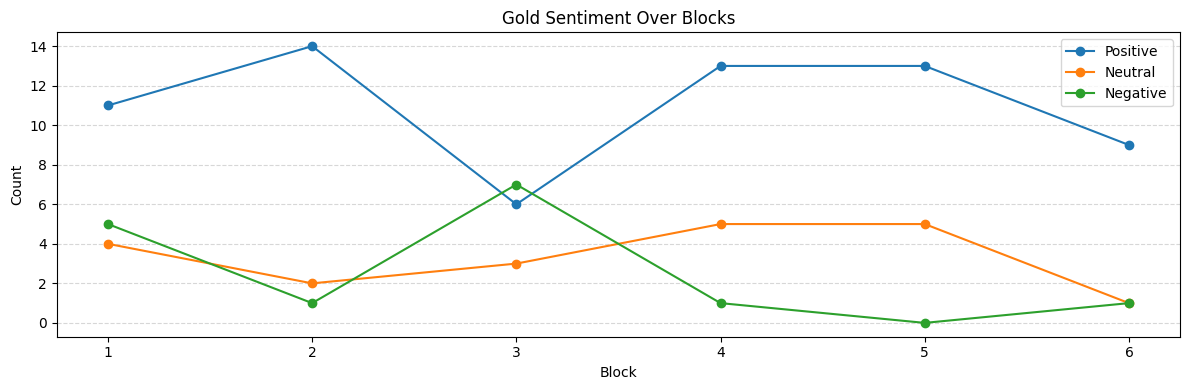

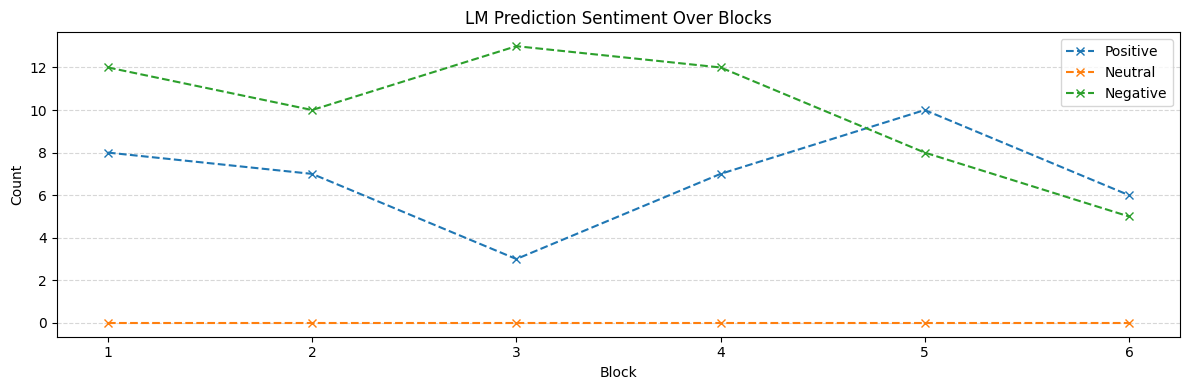

In [ ]:
plot_sentiment_timeseries("per_evaluation_binary.xlsx", "Winter_2020")

In [ ]:
def plot_sentiment_bars(input_excel, semester_value, normalize=False):
    """
    Plots sentiment as stacked bar charts per block
    - One chart for Gold labels
    - One chart for LM predictions
    - normalize=True -> plots proportions instead of raw counts
    """

    df = pd.read_excel(input_excel)
    df = df[df['Semester'] == semester_value].copy()

    blocks = sorted(df['Reaktionsblatt/Block'].unique())

    # --- Aggregate Gold labels ---
    gold_counts = df.groupby('Reaktionsblatt/Block')[
        ['Label_Positive', 'Label_Neutral', 'Label_Negative']
    ].sum().reindex(blocks, fill_value=0)

    if normalize:
        gold_counts = gold_counts.div(gold_counts.sum(axis=1), axis=0)

    # Stacked bar chart for Gold
    plt.figure(figsize=(12, 4))
    plt.bar(blocks, gold_counts['Label_Positive'], label='Positive', color='green')
    plt.bar(blocks, gold_counts['Label_Neutral'], bottom=gold_counts['Label_Positive'], label='Neutral', color='gray')
    plt.bar(blocks, gold_counts['Label_Negative'], bottom=gold_counts['Label_Positive'] + gold_counts['Label_Neutral'], label='Negative', color='red')

    plt.title("Gold Sentiment per Block")
    plt.xlabel("Block")
    plt.ylabel("Count" if not normalize else "Proportion")
    plt.xticks(blocks)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Aggregate Predictions ---
    pred_counts = df.groupby('Reaktionsblatt/Block')[
        ['Prediction_Positive', 'Prediction_Neutral', 'Prediction_Negative']
    ].sum().reindex(blocks, fill_value=0)

    if normalize:
        pred_counts = pred_counts.div(pred_counts.sum(axis=1), axis=0)

    # Stacked bar chart for LM predictions
    plt.figure(figsize=(12, 4))
    plt.bar(blocks, pred_counts['Prediction_Positive'], label='Positive', color='green')
    plt.bar(blocks, pred_counts['Prediction_Neutral'], bottom=pred_counts['Prediction_Positive'], label='Neutral', color='gray')
    plt.bar(blocks, pred_counts['Prediction_Negative'], bottom=pred_counts['Prediction_Positive'] + pred_counts['Prediction_Neutral'], label='Negative', color='red')

    plt.title("LM Prediction Sentiment per Block")
    plt.xlabel("Block")
    plt.ylabel("Count" if not normalize else "Proportion")
    plt.xticks(blocks)
    plt.legend()
    plt.tight_layout()
    plt.show()


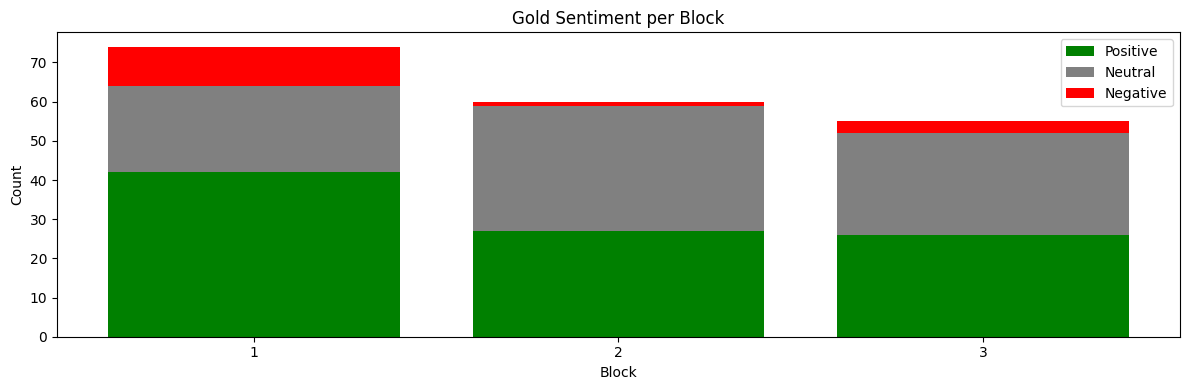

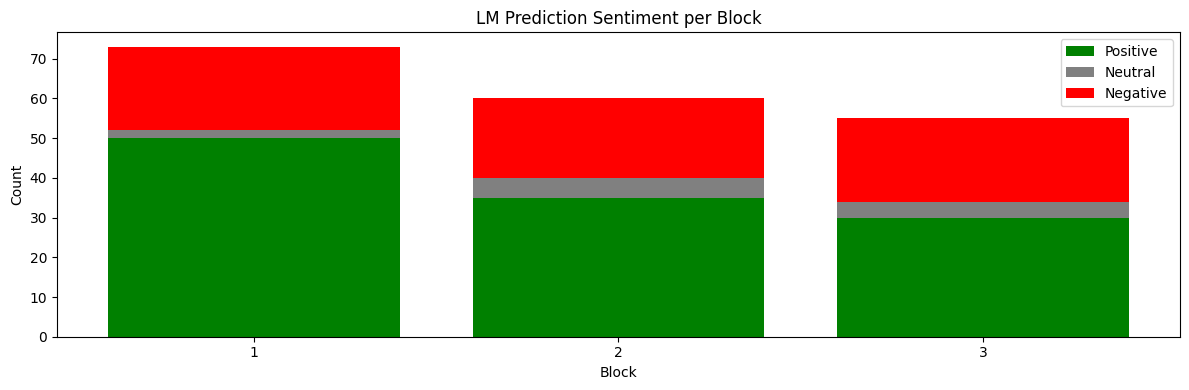

In [ ]:
plot_sentiment_bars("per_sentence_binary.xlsx", "Winter_2022")

In [ ]:
def compute_confusion_matrix(input_excel):
    # Read Excel file
    df = pd.read_excel(input_excel)

    # Define label columns
    gold_cols = ['Label_Positive', 'Label_Neutral', 'Label_Negative']
    pred_cols = ['Prediction_Positive', 'Prediction_Neutral', 'Prediction_Negative']

    # Convert one-hot encoding to class labels
    df['Gold_Label'] = df[gold_cols].idxmax(axis=1).str.replace('Label_', '')
    df['Predicted_Label'] = df[pred_cols].idxmax(axis=1).str.replace('Prediction_', '')

    # Define label order (important for consistency)
    labels = ['Positive', 'Neutral', 'Negative']

    # Compute confusion matrix
    cm = confusion_matrix(
        df['Gold_Label'],
        df['Predicted_Label'],
        labels=labels
    )

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix (Sentence-Level Sentiment Analysis)')
    plt.show()

    return cm


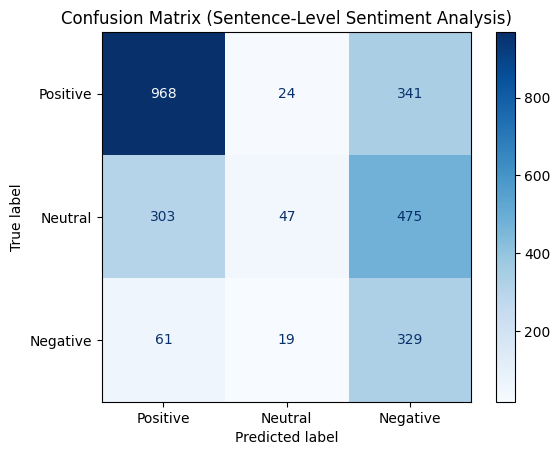

[[968  24 341]
 [303  47 475]
 [ 61  19 329]]


In [ ]:
cm = compute_confusion_matrix("per_sentence_binary.xlsx")
print(cm)


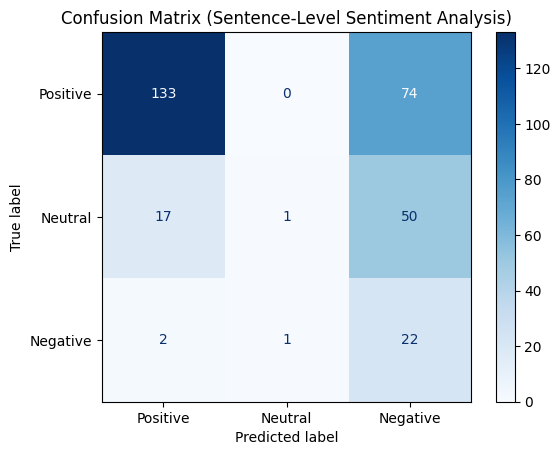

[[133   0  74]
 [ 17   1  50]
 [  2   1  22]]


In [ ]:
cm_evaluation = compute_confusion_matrix("per_evaluation_binary.xlsx")
print(cm_evaluation)

In [ ]:
def evaluate_from_confusion_matrix(cm):
    """
    Computes evaluation metrics from a confusion matrix
    with class order: [Positive, Neutral, Negative].
    """

    labels = ["Positive", "Neutral", "Negative"]
    cm = np.array(cm)

    # Reconstruct gold and predicted labels
    y_true = []
    y_pred = []

    for gold_idx, gold_label in enumerate(labels):
        for pred_idx, pred_label in enumerate(labels):
            count = cm[gold_idx, pred_idx]
            y_true.extend([gold_label] * count)
            y_pred.extend([pred_label] * count)

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        average=None
    )

    # Aggregated metrics
    f1_macro = precision_recall_fscore_support(
        y_true, y_pred, average="macro"
    )[2]

    f1_micro = precision_recall_fscore_support(
        y_true, y_pred, average="micro"
    )[2]

    f1_weighted = precision_recall_fscore_support(
        y_true, y_pred, average="weighted"
    )[2]

    return {
        "accuracy": accuracy,
        "precision_per_class": dict(zip(labels, precision)),
        "recall_per_class": dict(zip(labels, recall)),
        "f1_per_class": dict(zip(labels, f1)),
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted
    }


In [ ]:
evaluate_from_confusion_matrix(cm)

{'accuracy': 0.5235683677444488,
 'precision_per_class': {'Positive': np.float64(0.7267267267267268),
  'Neutral': np.float64(0.5222222222222223),
  'Negative': np.float64(0.2873362445414847)},
 'recall_per_class': {'Positive': np.float64(0.7261815453863466),
  'Neutral': np.float64(0.05696969696969697),
  'Negative': np.float64(0.80440097799511)},
 'f1_per_class': {'Positive': np.float64(0.726454033771107),
  'Neutral': np.float64(0.10273224043715846),
  'Negative': np.float64(0.42342342342342343)},
 'f1_macro': 0.41753656587722965,
 'f1_micro': 0.5235683677444488,
 'f1_weighted': 0.4777162078526379}

In [ ]:
evaluate_from_confusion_matrix(cm_evaluation)

{'accuracy': 0.52,
 'precision_per_class': {'Positive': np.float64(0.875),
  'Neutral': np.float64(0.5),
  'Negative': np.float64(0.1506849315068493)},
 'recall_per_class': {'Positive': np.float64(0.642512077294686),
  'Neutral': np.float64(0.014705882352941176),
  'Negative': np.float64(0.88)},
 'f1_per_class': {'Positive': np.float64(0.7409470752089137),
  'Neutral': np.float64(0.02857142857142857),
  'Negative': np.float64(0.2573099415204678)},
 'f1_macro': 0.3422761484336034,
 'f1_micro': 0.52,
 'f1_weighted': 0.5391721674970466}

In [ ]:
def mild_severe_error_rates(conf_matrix):
    """
    Computes mild and severe error rates from a 3-class confusion matrix.

    Class order must be:
    [Positive, Neutral, Negative]

    Rows: gold labels
    Columns: predicted labels
    """

    conf_matrix = np.array(conf_matrix)

    # Total number of samples
    total_samples = conf_matrix.sum()

    # Correct predictions (diagonal)
    correct = np.trace(conf_matrix)

    # Total errors
    total_errors = total_samples - correct

    if total_errors == 0:
        return {
            "mild_error_rate": 0.0,
            "severe_error_rate": 0.0
        }

    # Mild errors (adjacent classes)
    mild_errors = (
        conf_matrix[0, 1] +  # Positive → Neutral
        conf_matrix[1, 0] +  # Neutral → Positive
        conf_matrix[1, 2] +  # Neutral → Negative
        conf_matrix[2, 1]    # Negative → Neutral
    )

    # Severe errors (opposite classes)
    severe_errors = (
        conf_matrix[0, 2] +  # Positive → Negative
        conf_matrix[2, 0]    # Negative → Positive
    )

    mild_error_rate = mild_errors / total_errors
    severe_error_rate = severe_errors / total_errors

    return {
        "mild_error_rate": mild_error_rate,
        "severe_error_rate": severe_error_rate
    }


In [ ]:
rates = mild_severe_error_rates(cm)

print("Mild error rate:", rates["mild_error_rate"])
print("Severe error rate:", rates["severe_error_rate"])

Mild error rate: 0.6713000817661489
Severe error rate: 0.3286999182338512


In [ ]:
rates_evaluation = mild_severe_error_rates(cm_evaluation)

print("Mild error rate:", rates_evaluation["mild_error_rate"])
print("Severe error rate:", rates_evaluation["severe_error_rate"])

Mild error rate: 0.4722222222222222
Severe error rate: 0.5277777777777778
